# Libraries

In [6]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import cobaya as cby
from mpi4py import MPI, __version__
import pandas as pd
%matplotlib inline
from astropy.io import fits

print(__version__ if MPI.COMM_WORLD.Get_rank() else '')



In [ ]:
def clmap(mapa, LMAX = 2507):
    hp.mollview(
    mapa*1e6,
    coord=["G"],
    title="Histogram equalized Galactic of COMMANDER 100 GHz",
    unit="muK",
    norm="hist")
    hp.graticule() 

    
    
    cl = hp.anafast(mapa*1e6, lmax=LMAX)
    ell = np.linspace(start=2,stop=len(cl)+2,dtype=int)
    print(len(cl))

    D_ell = (ell * (ell + 1)) * cl/(2*np.pi)
    errors = (unbin_cl[' -dDl           '],unbin_cl[' +dDl'])

    # Create a figure and grid for subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    fig.subplots_adjust(hspace=0)
    fig.set_size_inches(15,10)
    # Top subplot
    ax1.errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
    ax1.set_ylabel('$D_\ell^{TT} \, [\mu K^2]$')
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Bottom subplot (Residuals)
    delta_D_ell = np.array(D_ell) - np.array(data[data.columns[1]].astype(float))

    ax2.errorbar(ell[3:], delta_D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
    ax2.set_ylabel('$\Delta D_\ell^{TT}$')
    ax2.set_xlabel('$\ell$')
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax1.title.set_text("Power Spectrum of TT from CMB Commander 100 GHz")
    ax1.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
    ax2.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
    # Show plot
    plt.xscale('log')
    plt.yscale('linear')
    plt.show()

# Experimental Data

## Data from Planck Legacy Archive

In [15]:



unbin_cl = pd.read_csv('maps/COM_PowerSpect_CMB-TT-full_R3.01.txt', sep=',')

unbin_cl.head()

unbin_cl.columns = ['ell', 'D_ell', '-dD_ell', '+dD_ell']

unbin_cl.head()

,ell,D_ell,-dD_ell,+dD_ell
0,2.0,225.895,132.369,533.062
1,3.0,936.920,450.471,1212.308
2,4.0,692.238,294.111,666.469
3,5.0,1501.705,574.432,1155.804
4,6.0,557.611,201.242,375.763


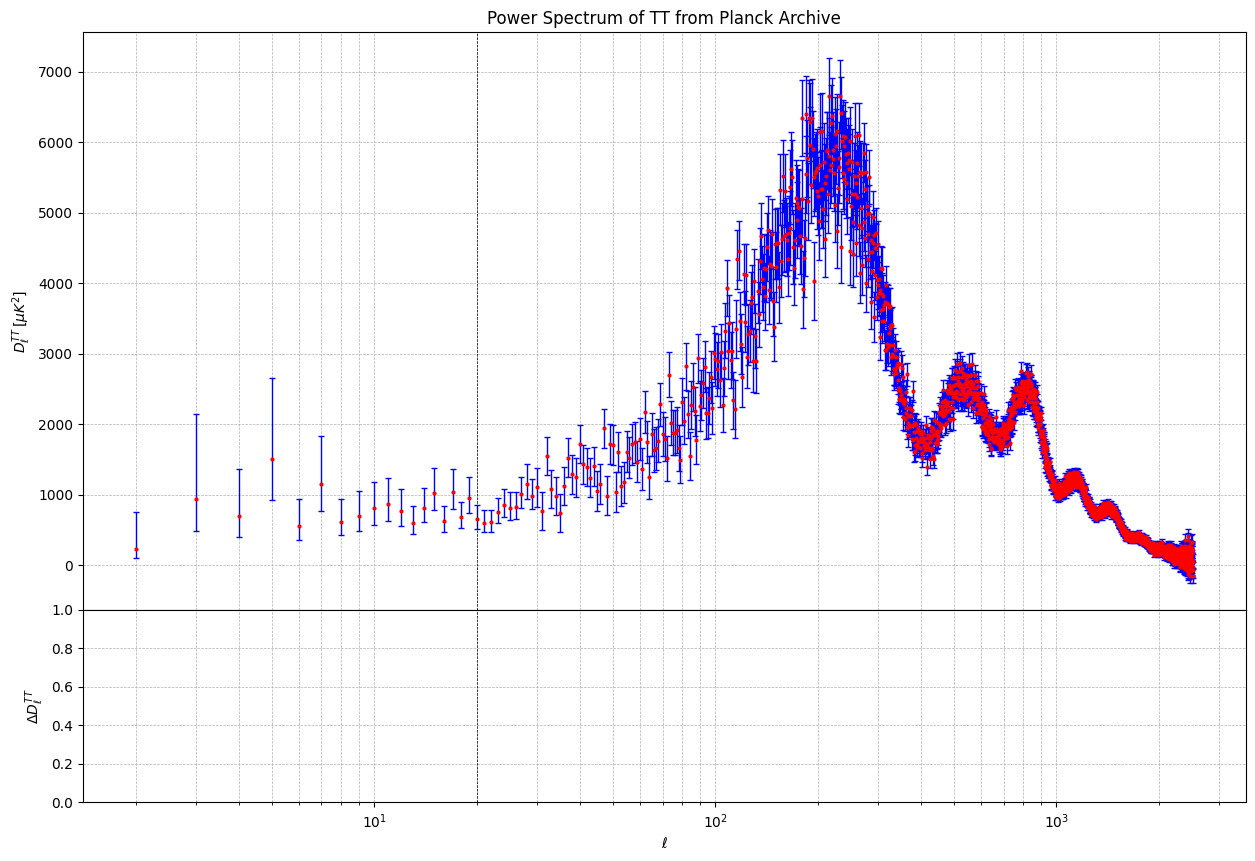

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ell = unbin_cl['ell']
D_ell = unbin_cl['D_ell']
errors = (unbin_cl['-dD_ell'],unbin_cl['+dD_ell'])

# Create a figure and grid for subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)
fig.set_size_inches(15,10)
# Top subplot
ax1.errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax1.set_ylabel('$D_\ell^{TT} \, [\mu K^2]$')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Bottom subplot (Residuals)
delta_D_ell = np.array(D_ell[:-1]) - np.array(D_ell[1:])

#ax2.errorbar(ell, delta_D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax2.set_ylabel('$\Delta D_\ell^{TT}$')
ax2.set_xlabel('$\ell$')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.title.set_text("Power Spectrum of TT from Planck Archive Unbinned")
ax1.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
ax2.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
# Show plot
plt.xscale('log')
plt.yscale('linear')
plt.show()



In [24]:

bin_cl = pd.read_csv('maps/COM_PowerSpect_CMB-TT-binned_R3.01.txt', sep=',')

bin_cl.head()

bin_cl.columns = ['ell', 'D_ell', '-dD_ell', '+dD_ell','BestFit']

bin_cl.head()

,ell,D_ell,-dD_ell,+dD_ell,BestFit
0,47.711224,1479.33552,50.765488,50.765488,1461.11304
1,76.471606,2034.96833,54.710158,54.710158,2062.38073
2,105.917385,2955.39416,64.976644,64.976644,2904.52526
3,135.605348,3869.51392,76.914374,76.914374,3902.48963
4,165.405597,4889.46506,86.585626,86.585626,4861.35537


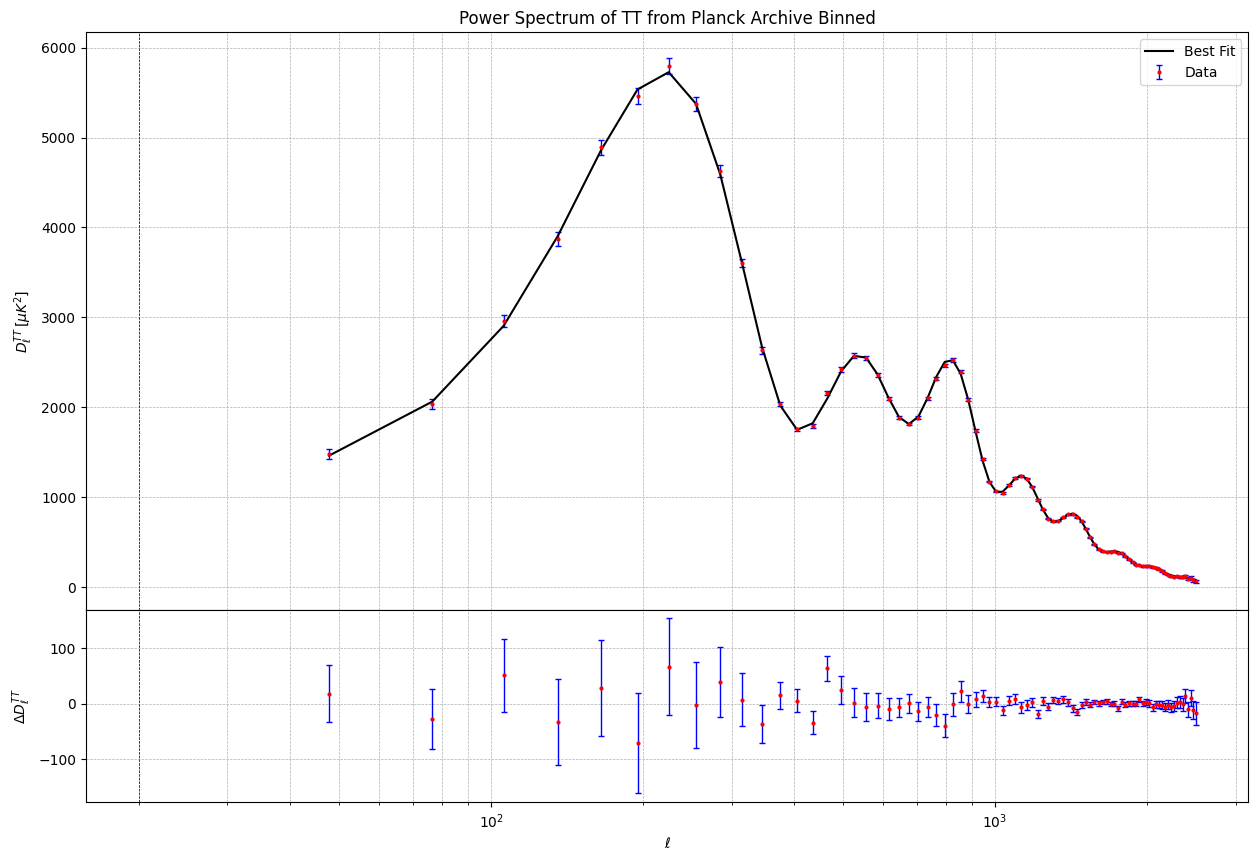

In [25]:
ell = bin_cl['ell']
D_ell = bin_cl['D_ell']
errors = (bin_cl['-dD_ell'],bin_cl['+dD_ell'])

# Create a figure and grid for subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)
fig.set_size_inches(15,10)
# Top subplot
ax1.errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2, label='Data')
ax1.plot(ell, bin_cl['BestFit'], color='black', label='Best Fit')
ax1.set_ylabel('$D_\ell^{TT} \, [\mu K^2]$')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.legend(loc='upper right')
# Bottom subplot (Residuals)
delta_D_ell = np.array(D_ell) - np.array(bin_cl['BestFit'])

ax2.errorbar(ell, delta_D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax2.set_ylabel('$\Delta D_\ell^{TT}$')
ax2.set_xlabel('$\ell$')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.title.set_text("Power Spectrum of TT from Planck Archive Binned")
ax1.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
ax2.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
# Show plot
plt.xscale('log')
plt.yscale('linear')
plt.show()

## Commander map

In [11]:
com_full_Hz = hp.read_map("maps/COM_CMB_IQU-commander_2048_R3.00_full.fits",field=5)


[healpy] NSIDE = 2048
[healpy] ORDERING = NESTED in fits file
[healpy] No INDXSCHM keyword in header file: assume IMPLICIT
[healpy] INDXSCHM = IMPLICIT
[healpy] Ordering converted to RING


2507
2507
2507
132.369


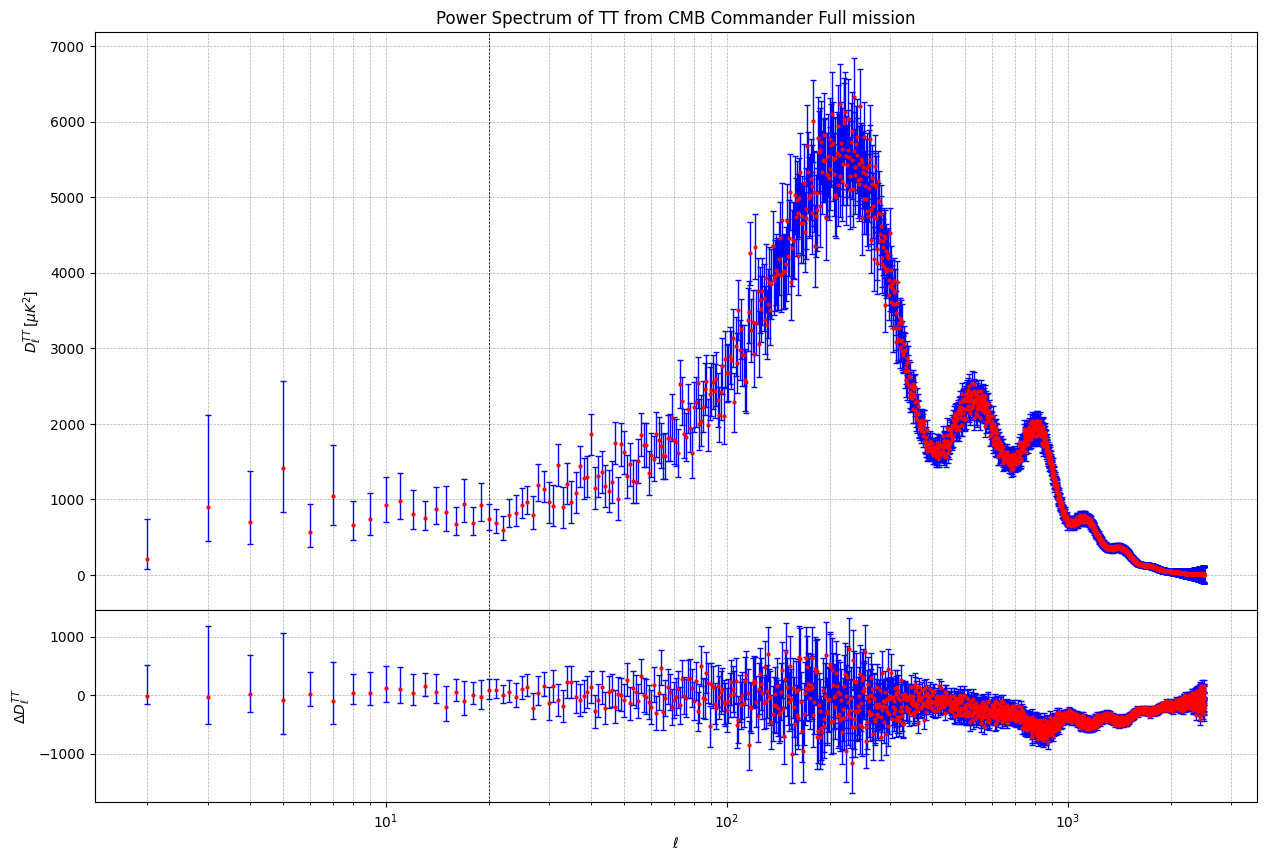

In [20]:
LMAX = 2508
cl = hp.anafast(com_full_Hz*1e6, lmax=LMAX)
#ell = np.arange(start=2,stop=LMAX,dtype=int)
ell = unbin_cl['ell']

print(len(cl[2:]))
print(len(ell))

D_ell = (ell * (ell + 1)) * cl[2:]/(2*np.pi)
errors = (unbin_cl['-dD_ell'],unbin_cl['+dD_ell'])

print(len(errors[0]))
print(errors[0][0])
# Create a figure and grid for subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)
fig.set_size_inches(15,10)
# Top subplot
ax1.errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax1.set_ylabel('$D_\ell^{TT} \, [\mu K^2]$')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Bottom subplot (Residuals)
delta_D_ell = np.array(D_ell) - np.array(unbin_cl['D_ell'])

ax2.errorbar(ell, delta_D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax2.set_ylabel('$\Delta D_\ell^{TT}$')
ax2.set_xlabel('$\ell$')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.title.set_text("Power Spectrum of TT from CMB Commander Full mission")
ax1.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
ax2.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
# Show plot
plt.xscale('log')
plt.yscale('linear')
plt.show()

## Smica Map

In [18]:
smi_full_Hz = hp.read_map("maps/COM_CMB_IQU-smica_2048_R3.00_full.fits",field=5)


[healpy] NSIDE = 2048
[healpy] ORDERING = NESTED in fits file
[healpy] No INDXSCHM keyword in header file: assume IMPLICIT
[healpy] INDXSCHM = IMPLICIT
[healpy] Ordering converted to RING


2507
2507
2507
132.369


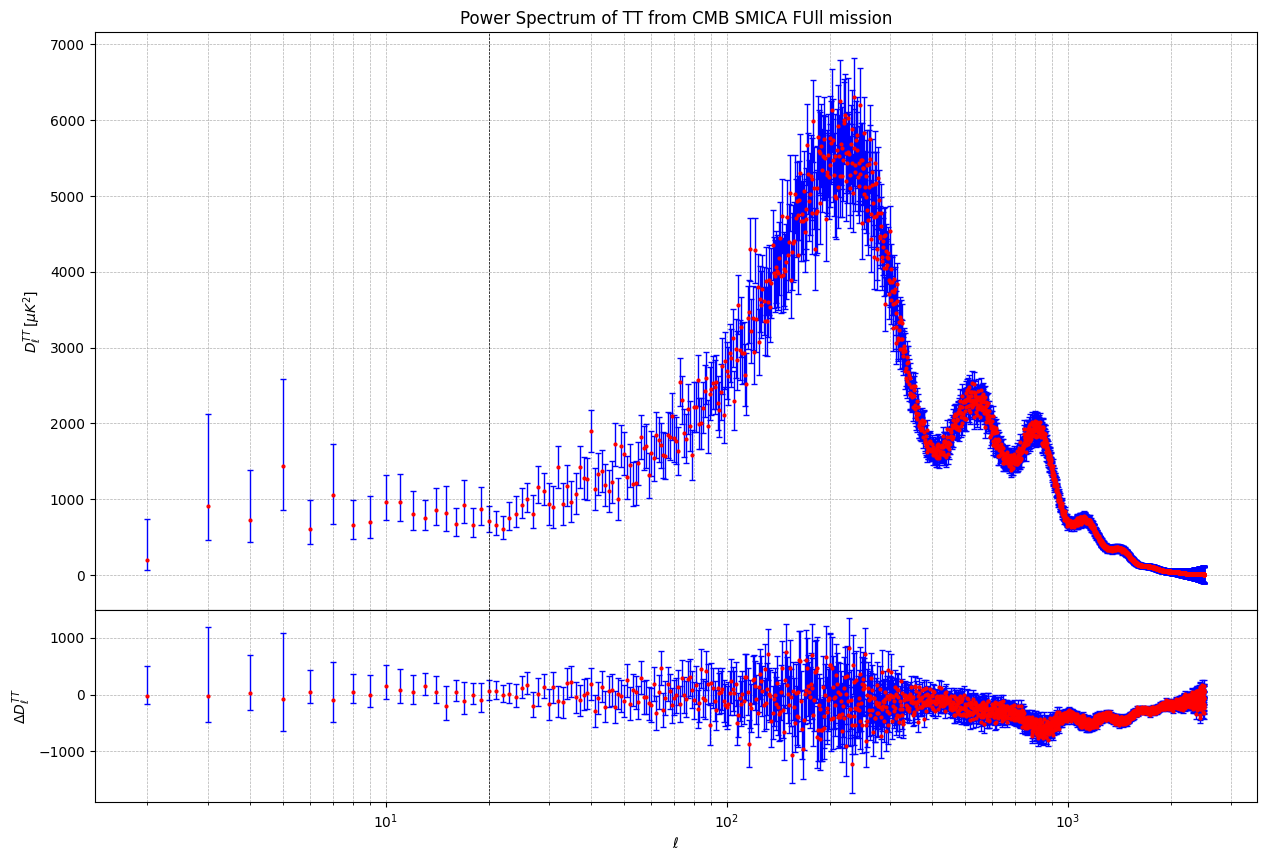

In [21]:
LMAX = 2508
cl = hp.anafast(smi_full_Hz*1e6, lmax=LMAX)

ell = unbin_cl['ell']

print(len(cl[2:]))
print(len(ell))

D_ell = (ell * (ell + 1)) * cl[2:]/(2*np.pi)
errors = (unbin_cl['-dD_ell'], unbin_cl['+dD_ell'])

print(len(errors[0]))
print(errors[0][0])
# Create a figure and grid for subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)
fig.set_size_inches(15,10)
# Top subplot
ax1.errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax1.set_ylabel('$D_\ell^{TT} \, [\mu K^2]$')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Bottom subplot (Residuals)
delta_D_ell = np.array(D_ell) - np.array(unbin_cl['D_ell'])

ax2.errorbar(ell, delta_D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax2.set_ylabel('$\Delta D_\ell^{TT}$')
ax2.set_xlabel('$\ell$')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.title.set_text("Power Spectrum of TT from CMB SMICA FUll mission")
ax1.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
ax2.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
# Show plot
plt.xscale('log')
plt.yscale('linear')
plt.show()

## Data from CMB sky maps

In [ ]:
fits_image_filename = "maps/COM_CMB_IQU-commander_2048_R3.00_full.fits"
hdu = fits.open(fits_image_filename)

In [ ]:
hdu[1].header

In [ ]:
normal = hp.read_map(fits_image_filename)
mascara = hp.read_map(fits_image_filename, field=3)
relleno = hp.read_map(fits_image_filename, field=5)

In [ ]:
%matplotlib inline
hp.mollview(
    relleno,
    coord=["G"],
    title="Relleno",
    unit="K_CMB",
    norm='hist')

In [ ]:
hp.mollview(
    mascara,
    coord=["G"],
    title="Mascara",
    unit="K_CMB",
    norm='hist')

hp.mollview(
    normal-mascara,
    coord=["G"],
    title="Normal-Mascara",
    unit="K_CMB",
    norm='hist')
hp.mollview(
    normal-relleno,
    coord=["G"],
    title="Normal-Relleno",
    unit="K_CMB",
    norm='hist')
hp.mollview(
    normal/relleno,
    coord=["G"],
    title="Normal/Relleno",
    unit="K_CMB",
    norm='hist')

In [ ]:
import candl.tests
candl.tests.run_all_tests()

# Simulations with CAMB

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import camb
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

In [ ]:
#Set up a new set of parameters for CAMB
#The defaults give one massive neutrino and helium set using BBN consistency
pars = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=-0.004, tau=0.06,  
                       As=2e-9, ns=0.965, halofit_version='mead', lmax=2507)

In [ ]:
results = camb.get_results(pars)

In [ ]:
powers =results.get_cmb_power_spectra(pars, CMB_unit='muK')
for name in powers: print(name)

In [ ]:
totCL=powers['total']
unlensedCL=powers['unlensed_scalar']
print(totCL.shape)
#Python CL arrays are all zero based (starting at L=0), Note L=0,1 entries will be zero by default.
#The different CL are always in the order TT, EE, BB, TE (with BB=0 for unlensed scalar results).
ls = np.arange(totCL.shape[0])
print(ls)
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].plot(ls,totCL[:,0], color='k', label='Total $C_l$')
ax[0,0].plot(ls,unlensedCL[:,0], color='C2', label='Unlensed $C_l$')
ax[0,0].set_title(r'$TT\, [\mu K^2]$')
ax[0,1].plot(ls[2:], 1-unlensedCL[2:,0]/totCL[2:,0]);
ax[0,1].set_title(r'Fractional TT lensing')
ax[1,0].plot(ls,totCL[:,1], color='k')
ax[1,0].plot(ls,unlensedCL[:,1], color='C2')
ax[1,0].set_title(r'$EE\, [\mu K^2]$')
ax[1,1].plot(ls,totCL[:,3], color='k')
ax[1,1].plot(ls,unlensedCL[:,3], color='C2')
ax[1,1].set_title(r'$TE\, [\mu K^2]$');
for ax in ax.reshape(-1): 
    ax.set_xlim([2,3000])
    ax.set_xlabel(r'$\ell$');
    ax.legend()

In [ ]:
print(totCL.shape)

In [ ]:
import camb.correlations

ell = np.linspace(start=2,stop=totCL.shape[0],dtype=int)
xvals = np.linspace(-0.999,0.999,1000)
theta=np.arccos(xvals)

corrs = camb.correlations.cl2corr(totCL,xvals)

fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].plot(theta,corrs[:,0], color='k')
ax[0,0].set_title(r'$TT\, [\mu K^2]$')
ax[0,1].plot(theta, corrs[:,2]);
ax[0,1].set_title(r'BB')
ax[1,0].plot(theta,corrs[:,1], color='k')
ax[1,0].set_title(r'$EE\, [\mu K^2]$')
ax[1,1].plot(theta,corrs[:,3], color='k')
ax[1,1].set_title(r'$TE\, [\mu K^2]$');
for ax in ax.reshape(-1): 
    ax.set_xlabel(r'$\theta [rad]$');

# Likelihood

In [1]:
import cobaya
from cobaya.model import get_model
from cobaya.run import run
from getdist import plots, MCSamples
import matplotlib.pyplot as plt
import camb
import numpy as np
from concurrent.futures import ProcessPoolExecutor


In [2]:
# Basic example to compute CMB power spectrum quickly using Cobaya and CAMB

from cobaya.run import run

# Define the configuration dictionary with a quick theory evaluation setup
info = {
    "params": {
        "H0": 67.5,
        "ombh2": 0.022,
        "omch2": 0.122,
        "As": 2.1e-9,
        "ns": 0.965,
        "tau": 0.06,
    },
    "theory": {
        "camb": {
            "extra_args": {
                "omk": 0,
                "Alens": 1,
            }
        }
    },
    "likelihood": {
        "planck_2018_lowl.TT": None,
        "planck_2020_hillipop.TT": None
    },
    "sampler": {
        "mcmc": {"max_samples": 10000,
            "Rminus1_stop": 0.01,  # Default convergence criterion 0.01
            "Rminus1_cl_stop": 0.2,
            }
        },
}

# Run cobaya to evaluate theory quickly
updated_info, sampl = run(info)

# Extract CAMB results and get C_l
camb_results = updated_info["theory"]["camb"]

# Calculate the CMB power spectra
cls = camb_results.get_Cls()

# Print first few multipole moments of CMB TT power spectrum
print("ℓ     C_ℓ^TT")
for ell in range(2, 10):  # Just for quick visualization
    print(f"{ell}   {cls['tt'][ell]:.2e}")

[camb] `camb` module loaded successfully from /root/Research/Yago/yago_research/lib/python3.10/site-packages/camb
[planck_2020_hillipop.tt] Initialized!
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: A_planck:0.9964205, cal100A:1, cal100B:1, cal143B:1, cal217A:1, cal217B:1, Aradio:60, Adusty:6, AdustT:1, beta_dustT:1.51, Acib:4, beta_cib:1.75, Atsz:3, Aksz:1, xi:0.1
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {planck_2018_lowl.TT: 959.0, planck_2020_hillipop.TT: 31.7, camb.transfers: 2.4, camb: 0.875}
[mcmc] Covariance matrix not present. We will start learning the covariance of the proposal earlier: R-1 = 30 (would be 2 if all params loaded).
[mcmc] Sampling!
[mcmc] Progress @ 2025-02-25 22:51:42 : 1 steps taken, and 0 accepted.
[mcmc] Progress @ 2025-02-25 22:52:42 : 3208 steps taken, and 200 accepted.
[mcmc] Progress @ 2025-02-25 22:53:42 : 6655 steps taken, and 408 accepted.
[mcmc] Learn +

AttributeError: 'dict' object has no attribute 'get_Cls'

In [3]:
print(updated_info)

{'sampler': {'mcmc': {'burn_in': 0, 'max_tries': '40d', 'covmat': None, 'covmat_params': None, 'proposal_scale': 2.4, 'output_every': '60s', 'learn_every': '40d', 'temperature': 1, 'learn_proposal': True, 'learn_proposal_Rminus1_max': 2.0, 'learn_proposal_Rminus1_max_early': 30.0, 'learn_proposal_Rminus1_min': 0.0, 'max_samples': 10000, 'Rminus1_stop': 0.01, 'Rminus1_cl_stop': 0.2, 'Rminus1_cl_level': 0.95, 'Rminus1_single_split': 4, 'measure_speeds': True, 'oversample_power': 0.4, 'oversample_thin': True, 'drag': False, 'blocking': [(np.int64(1), ['A_planck']), (np.int64(1), ['cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi'])], 'callback_function': None, 'callback_every': None, 'seed': None, 'check_every': None, 'oversample': None, 'drag_limits': None, 'fallback_covmat_scale': 4, 'version': '3.5.4'}}, 'theory': {'camb': {'version': '1.5.9', 'path': None, 'speed': 0.3, 'stop_at_error': False, 'ex

In [5]:
print(sampl)

mcmc


In [ ]:

# Configuration dictionary
info = {
    "params": {
        "H0": 67.5,
        "ombh2": 0.022,
        "omch2": 0.122,
        "As": 2.1e-9,
        "ns": 0.965,
        "tau": 0.06,
    },
    "theory": {
        "camb": {
            "extra_args": {
                "omk": 0,
                "Alens": 1,
            }
        }
    },
    "likelihood": {
        "planck_2018_lowl.TT": None,
        "planck_2020_hillipop.TT": None
    },
    "sampler": {
        "mcmc": None
        },
}

# Run Cobaya
updated_info, products = run(info,debug=True)

# Load results with GetDist to get the best-fit parameters
samples = MCSamples(root='chains/example', ignore_rows=0.3)
best_fit_params = samples.getBestFit()

# Extract best-fit cosmological parameters
H0 = best_fit_params.getParam('H0').best_fit
ombh2 = best_fit_params.getParam('ombh2').best_fit
omch2 = best_fit_params.getParam('omch2').best_fit
As = best_fit_params.getParam('As').best_fit
ns = best_fit_params.getParam('ns').best_fit
tau = best_fit_params.getParam('tau').best_fit

# Set up CAMB parameters with best-fit values
pars = camb.read_ini("https://tinyurl.com/planck2018")
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, tau=tau)
pars.InitPower.set_params(As=As, ns=ns)

# Compute results
results = camb.get_results(pars)
cls = results.get_cmb_power_spectra(pars, lmax=2500, CMB_unit='muK')['total']

# Plot the CMB power spectrum
plt.figure(figsize=(10, 6))
plt.plot(cls[:, 0], cls[:, 1], label='TT')
plt.plot(cls[:, 0], cls[:, 2], label='EE')
plt.plot(cls[:, 0], cls[:, 3], label='BB')
plt.plot(cls[:, 0], cls[:, 4], label='TE')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell$')
plt.title('CMB Power Spectrum')
plt.legend()
plt.grid(True)
plt.show()





In [ ]:
from cobaya.model import get_model
from cobaya.run import run
import numpy as np
import matplotlib.pyplot as plt

# Configuration dictionary
info = {
    "params": {
        "H0": 67.5,
        "ombh2": 0.022,
        "omch2": 0.122,
        "As": 2.1e-9,
        "ns": 0.965,
        "tau": 0.06,
    },
    "theory": {
        "camb": {
            "extra_args": {
                "omk": 0,
                "Alens": 1,
            }
        }
    },
    "likelihood": {
        "planck_2018_lowl.TT": None,
        "planck_2020_hillipop.TT": None
    },
    "sampler": {
        "mcmc": {
            "max_samples": 100000
        }
    },
    "output": "chains/example",
    "mcmc": {
        "Rminus1_stop": 0.01
    },
}

# Run Cobaya
updated_info, products = run(info)

# Retrieve likelihood values and parameter samples
model = get_model(info)
like = model.loglikes[0]  # Assuming a single likelihood is defined

# Iterate over samples to compute likelihood for each set of parameters
likelihoods = []
for sample in products['sample']:
    params_dict = dict(zip(products['param.names'], sample))    
    model.logposterior(params_dict)
    likelihoods.append(like)

# Convert likelihood values for plotting
likelihoods = np.array(likelihoods)

# Plot the likelihood
plt.figure(figsize=(8, 6))
plt.plot(likelihoods, marker='o', linestyle='', alpha=0.5)
plt.xlabel('Sample Index')
plt.ylabel('Log Likelihood')
plt.title('Likelihood of the $C_\ell$ Power Spectrum')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from cobaya.run import run

# Function to compute likelihood for a given set of parameters
def compute_likelihood(params):
    info = {
        "likelihood": {
            "planck_2018_lowl.TT": None,
            "planck_2020_hillipop.TT": None
        },
        "sampler": {
        "mcmc": None
        },
        "theory": {
            "camb": {}
        },
        "params": params
    }
    updated_info, _ = run(info)
    return updated_info["likelihood"]["planck_2018_highl_plik.TTTEEE"].logp

# Range of parameters to evaluate (example for demonstration)
param_sets = [
    {"H0": H0, "ombh2": 0.022, "omch2": 0.12, "tau": 0.06, "ns": 0.965, "As": 2.1e-9}
    for H0 in np.linspace(60, 80, 10)  # Example: 10 different H0 values
]

# Use ProcessPoolExecutor to evaluate in parallel
if __name__ == '__main__':
    with ProcessPoolExecutor() as executor:
        likelihoods = list(executor.map(compute_likelihood, param_sets))

    # Print out the likelihoods
    print("List of parameters and likelihood")
    for params, likelihood in zip(param_sets, likelihoods):
        print(f"Parameters: {params}, Log Likelihood: {likelihood}")

In [ ]:
def compute_likelihood(params):
    try:
        info = {
            "likelihood": {
                
                "planck_2018_lowl.TT": None
            },
            "sampler": {"mcmc": None},
            "theory": {"camb": {}},
            "params": params
        }
        updated_info = run(info)
        return updated_info["logpost"]
    except Exception as e:
        print(f"Error processing {params}: {str(e)}")
        return -np.inf
    
param_sets = [
    {"H0": H0, "ombh2": 0.022, "omch2": 0.12, "tau": 0.06, "ns": 0.965, "As": 2.1e-9}
    for H0 in np.linspace(60, 80, 10)  # Example: 10 different H0 values
]

if __name__ == '__main__':
    # Limit number of workers (start with 1 for debugging)
    with ProcessPoolExecutor(max_workers=4) as executor:
        likelihoods = list(executor.map(compute_likelihood, param_sets))

# Print out the likelihoods
    print("List of parameters and likelihood for low $\ell$")
    for params, likelihood in zip(param_sets, likelihoods):
        print(f"Parameters: {params}, Log Likelihood: {likelihood}")

Parameter values from MCMC:
{'omegabh2': np.float64(0.022475881664888675), 'omegach2': np.float64(0.11776816154531217), 'theta': np.float64(1.04125509269275), 'tau': np.float64(0.1338110917465236), 'logA': np.float64(3.195601956334613), 'ns': np.float64(0.9730807516424419), 'aps100': np.float64(231.8185060641758), 'aps143': np.float64(34.827319422228896), 'aps217': np.float64(103.85743470059487), 'acib217': np.float64(37.355689192649095), 'asz143': np.float64(4.066695451514877), 'psr': np.float64(0.6759116830508232), 'cibr': np.float64(0.513446209059152), 'xi': np.float64(0.500528757318612), 'aksz': np.float64(4.123594806640074), 'dust100': np.float64(0.9975710343506784), 'dust143': np.float64(0.9507137129131603), 'dust217': np.float64(0.9804015988988629), 'dust143x217': np.float64(1.016369227207627), 'calPlanck': np.float64(1.0002062941482637), 'cal0': np.float64(0.9975444399426692), 'cal2': np.float64(1.0008606578875068), 'H0*': np.float64(68.35951352829821), 'omegal*': np.float64(0.

/tmp/ipykernel_3961/2752477696.py:36: RuntimeWarning: divide by zero encountered in divide
  ax[0,1].plot(ls[2:], 1-unlensed_cl[2:,0]/total_cl[2:,0]);
/tmp/ipykernel_3961/2752477696.py:36: RuntimeWarning: invalid value encountered in divide
  ax[0,1].plot(ls[2:], 1-unlensed_cl[2:,0]/total_cl[2:,0]);
/tmp/ipykernel_3961/2752477696.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


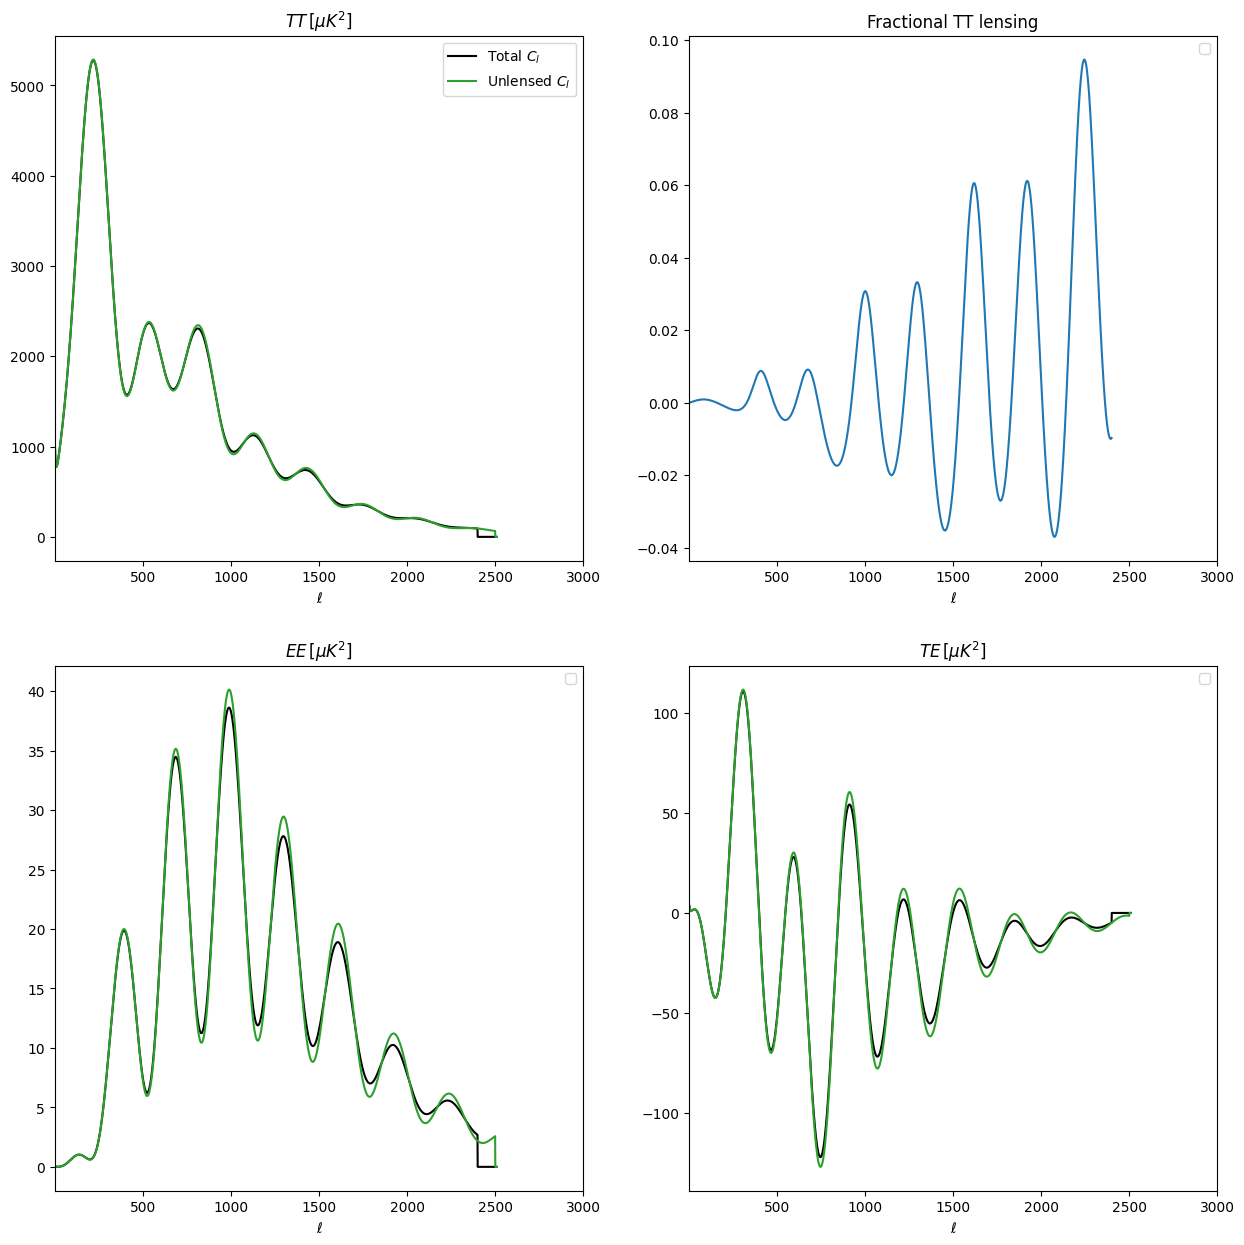

In [73]:
from getdist.mcsamples import loadMCSamples
from getdist import MCSamples
gd_sample = loadMCSamples("maps/COM_CosmoParams_fullGrid_R3.01/base/CamSpecHM_TT/base_CamSpecHM_TT")
param_names = str(gd_sample.getParamNames()).split(sep='\n')
param_values = gd_sample.getMeans()

#print([ch for ch in str(param_names)])
print("Parameter values from MCMC:")
param_dict = {}

# Populate the dictionary
for param, value in zip(param_names, param_values):
    # Remove the tab character and anything after it
    clean_param_name = param.split('\t')[0]
    param_dict[clean_param_name] = value
print(param_dict)
# Prepare parameters for CAMB using extracted values
pars = camb.CAMBparams()
pars.set_cosmology(H0=param_dict['H0*'], ombh2=param_dict['omegabh2'], omch2=param_dict['omegach2'])

# Set the initial power spectrum parameters
#pars.InitPower.set_params(As=1, ns=0)

# Run CAMB and get the results
results = camb.get_results(pars)

# Compute CMB power spectra (Cl's)
cls = results.get_cmb_power_spectra(pars, CMB_unit='muK',lmax=2508)
total_cl = cls['total']
unlensed_cl = results.get_unlensed_scalar_cls(CMB_unit='muK', lmax=2508)
ls = np.arange(total_cl.shape[0])
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].plot(ls,total_cl[:,0], color='k', label='Total $C_l$')
ax[0,0].plot(ls,unlensed_cl[:,0], color='C2', label='Unlensed $C_l$')
ax[0,0].set_title(r'$TT\, [\mu K^2]$')
ax[0,1].plot(ls[2:], 1-unlensed_cl[2:,0]/total_cl[2:,0]);
ax[0,1].set_title(r'Fractional TT lensing')
ax[1,0].plot(ls,total_cl[:,1], color='k')
ax[1,0].plot(ls,unlensed_cl[:,1], color='C2')
ax[1,0].set_title(r'$EE\, [\mu K^2]$')
ax[1,1].plot(ls,total_cl[:,3], color='k')
ax[1,1].plot(ls,unlensed_cl[:,3], color='C2')
ax[1,1].set_title(r'$TE\, [\mu K^2]$');
for ax in ax.reshape(-1): 
    ax.set_xlim([2,3000])
    ax.set_xlabel(r'$\ell$');
    ax.legend()

[root] *WARNING* Parameters are 100% correlated: omegal, omegam


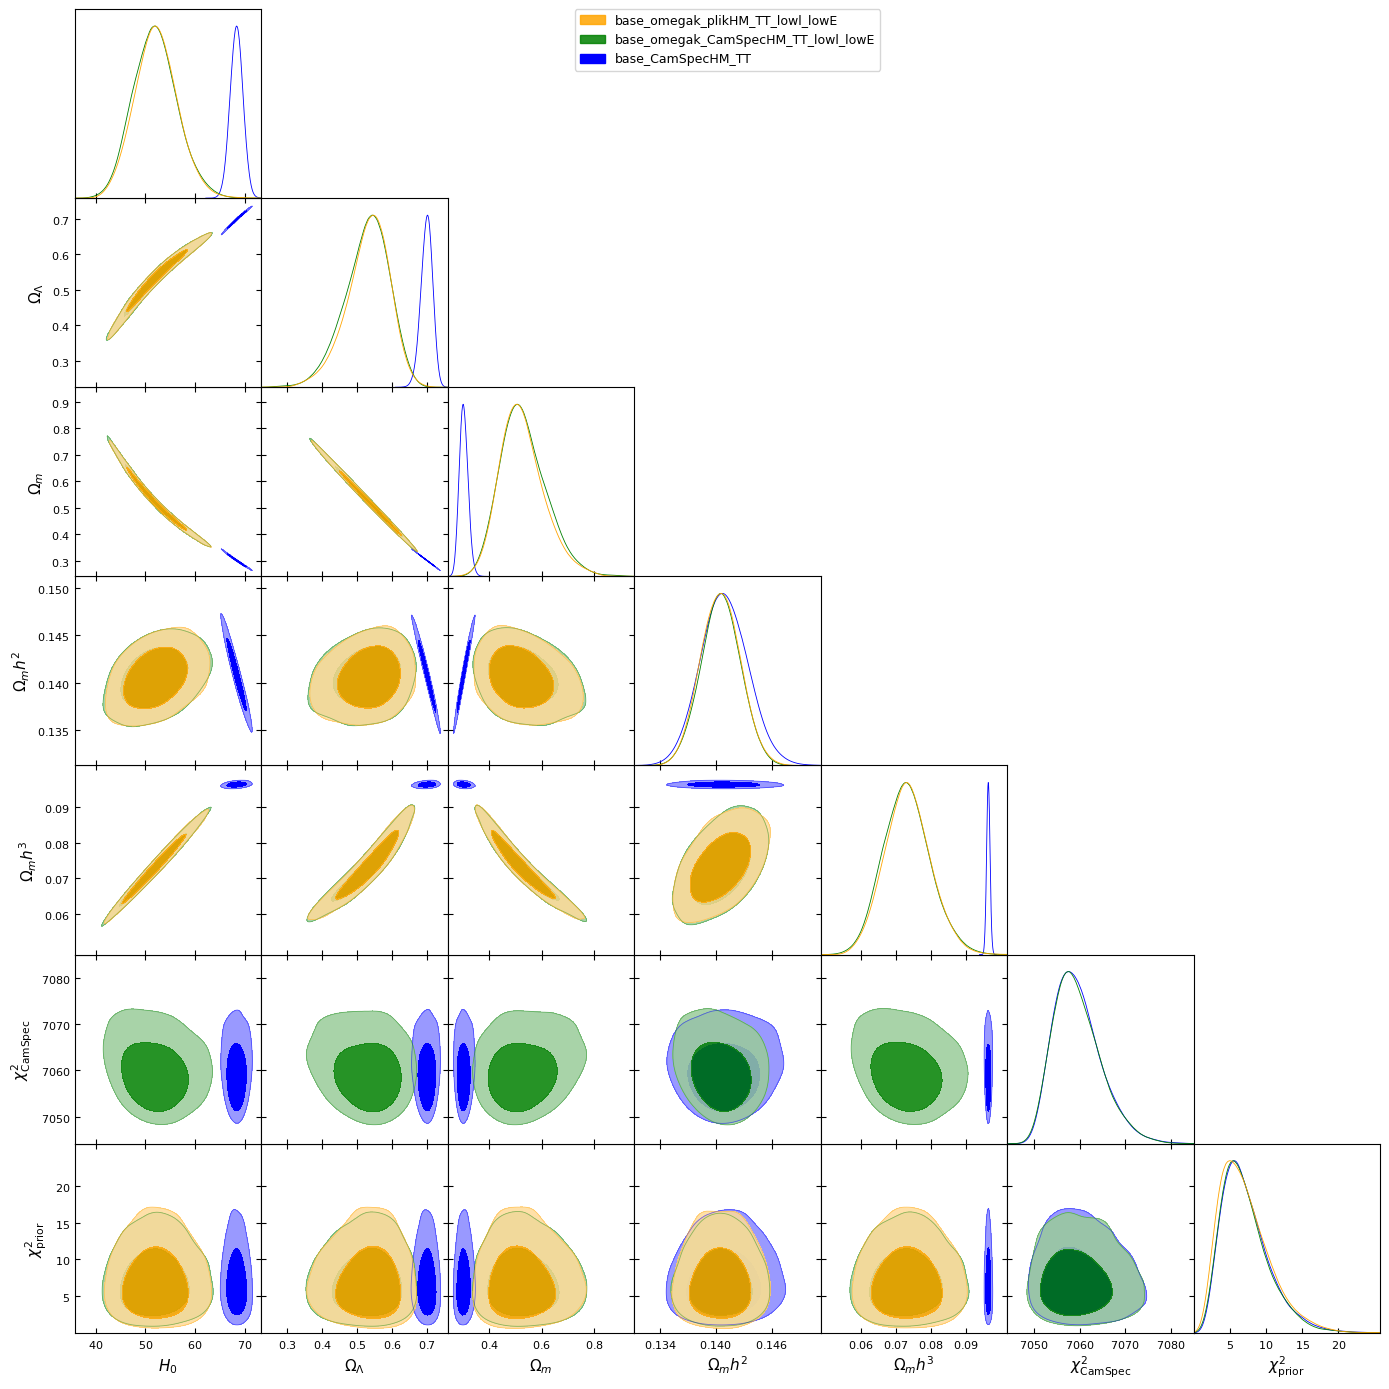

In [78]:
from getdist import plots

g=plots.get_subplot_plotter(chain_dir=r'/root/Research/Yago/maps/COM_CosmoParams_fullGrid_R3.01')
roots = ['base_CamSpecHM_TT', 'base_omegak_CamSpecHM_TT_lowl_lowE','base_omegak_plikHM_TT_lowl_lowE']
params =  ['H0', 'omegal', 'omegam', 'omegamh2', 'omegamh3', 'chi2_CamSpec', 'chi2_prior']
g.triangle_plot(roots, params, filled=True, label_order=-1, contour_colors=['blue', 'green', 'orange'])
g.export()